Accuracy: 1.0

Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix
[[1 0 0]
 [0 2 0]
 [0 0 2]]

Classification Report
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00         1
     Average       1.00      1.00      1.00         2
        Good       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Predicted Health Class: Average


c:\Users\rajni\ml-lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


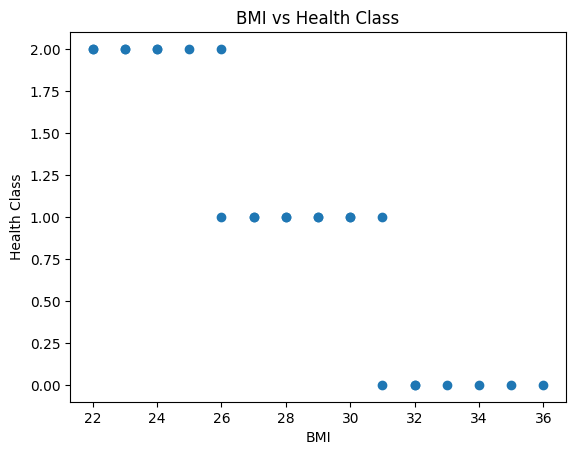

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("health_data.csv")


# Create 3-class target from HealthScore
# 0 = Poor
# 1 = Average
# 2 = Good

score = df["HealthScore"]

conditions = [
    score < 50,
    (score >= 50) & (score < 70),
    score >= 70
]

choices = [0,1,2]

df["HealthClass"] = np.select(conditions, choices)


# Features and target
X = df[["Age","BMI","ExerciseHours"]]
y = df["HealthClass"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Naive Bayes model
nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)


# Predictions
y_pred = nb_model.predict(X_test_scaled)


# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nPrecision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Poor","Average","Good"]
))


# Predict new sample
# Age = 35, BMI = 26, ExerciseHours = 3

input_data = [[35,26,3]]

input_scaled = scaler.transform(input_data)

prediction = nb_model.predict(input_scaled)[0]

labels = ["Poor","Average","Good"]

print("\nPredicted Health Class:", labels[prediction])


# Visualization
plt.scatter(df["BMI"], df["HealthClass"])

plt.xlabel("BMI")
plt.ylabel("Health Class")

plt.title("BMI vs Health Class")

plt.show()